# Customer Segmentation â€” Mall Customers

**Objective:** Segment mall customers into distinct groups based on their demographics and spending behavior using unsupervised machine learning (K-Means & DBSCAN).

**Dataset:** `Mall_Customers.csv` 200 records with 5 features:
- `CustomerID` Unique identifier
- `Gender`  Male / Female
- `Age`  Customer age
- `Annual Income (k$)`  Annual income in thousands of dollars
- `Spending Score (1-100)` Score assigned by the mall based on customer spending behavior

---

## 1. Imports & Setup

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(' All libraries imported successfully!')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Windows 11\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

## 2. Data Loading & Initial Inspection

In [ ]:
# Load dataset
df = pd.read_csv('Mall_Customers.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')
print('\n' + '='*60)
df.head(10)

Dataset Shape: (200, 5)
Number of Rows: 200
Number of Columns: 5



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [ ]:
# Data types and info
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Dataset Info ---')
df.info()

--- Data Types ---
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [ ]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [ ]:
# Check for missing values
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

--- Missing Values ---
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Gender Distribution

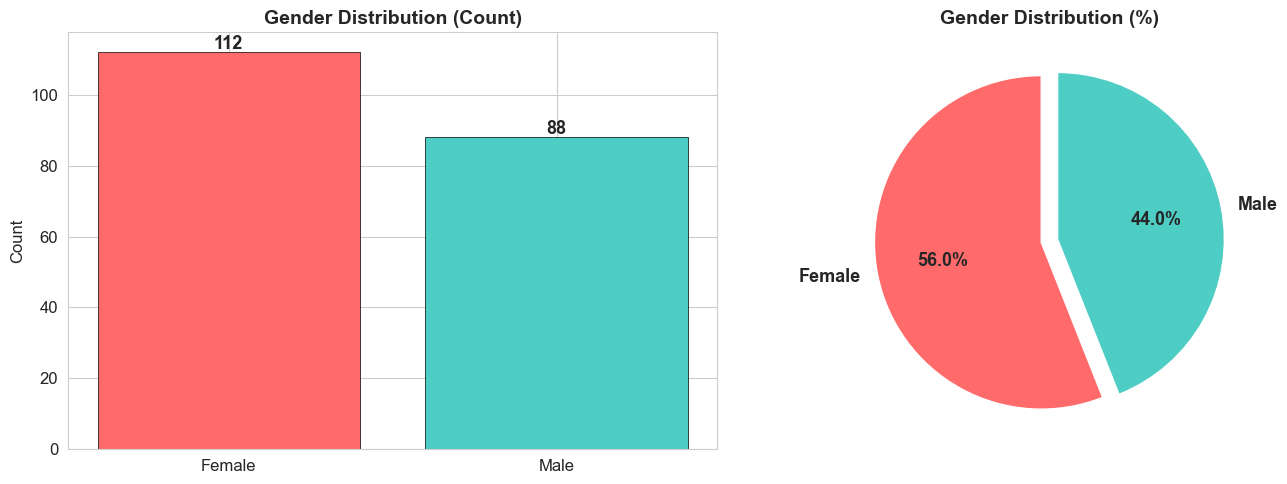

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#FF6B6B', '#4ECDC4']
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Gender Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[1].set_title('Gender Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 Distribution of Numerical Features

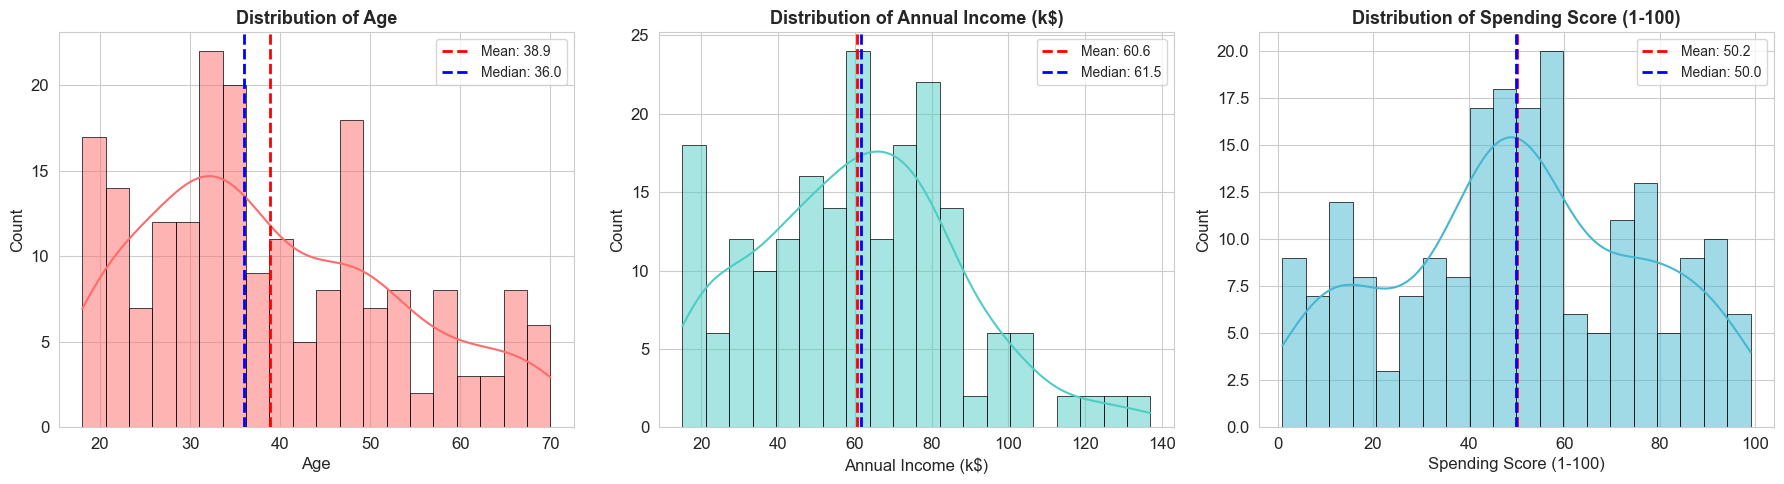

In [ ]:
num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=20, kde=True, color=palette[i], ax=axes[i], edgecolor='black', linewidth=0.5)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=10)

plt.tight_layout()
plt.show()

### 3.3 Box Plots  Outlier Detection

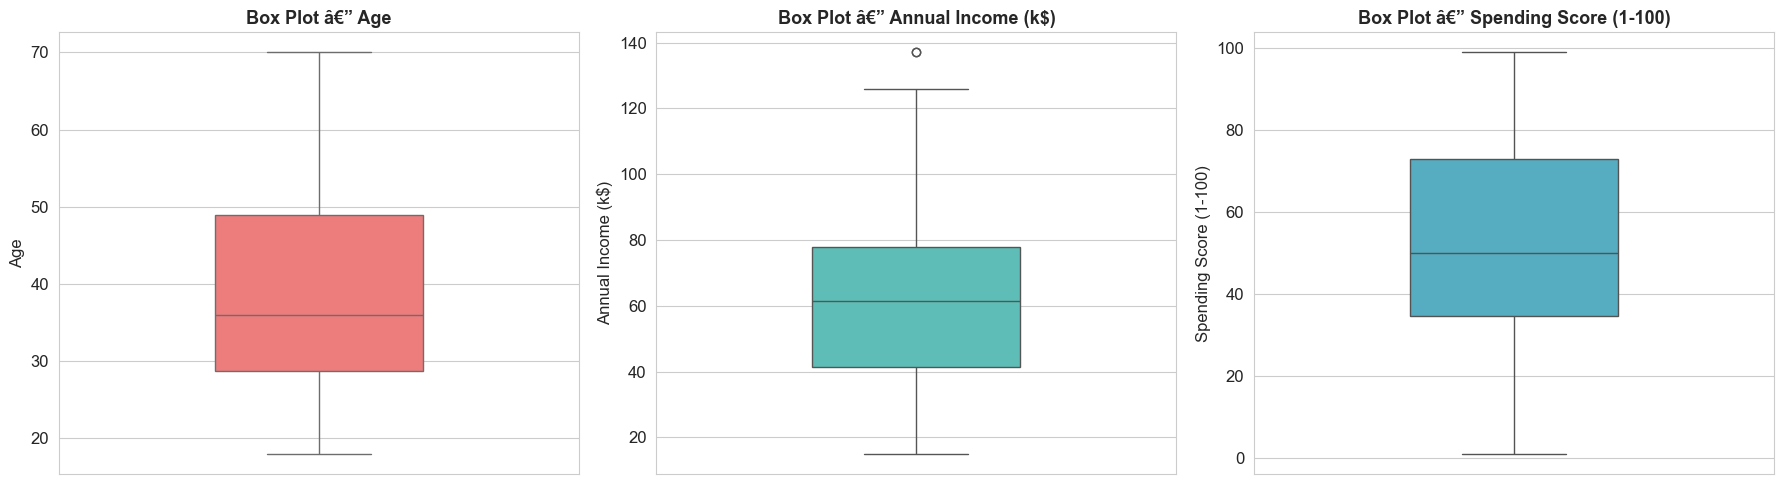

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], color=palette[i], ax=axes[i], width=0.4)
    axes[i].set_title(f'Box Plot â€” {col}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Box Plots by Gender

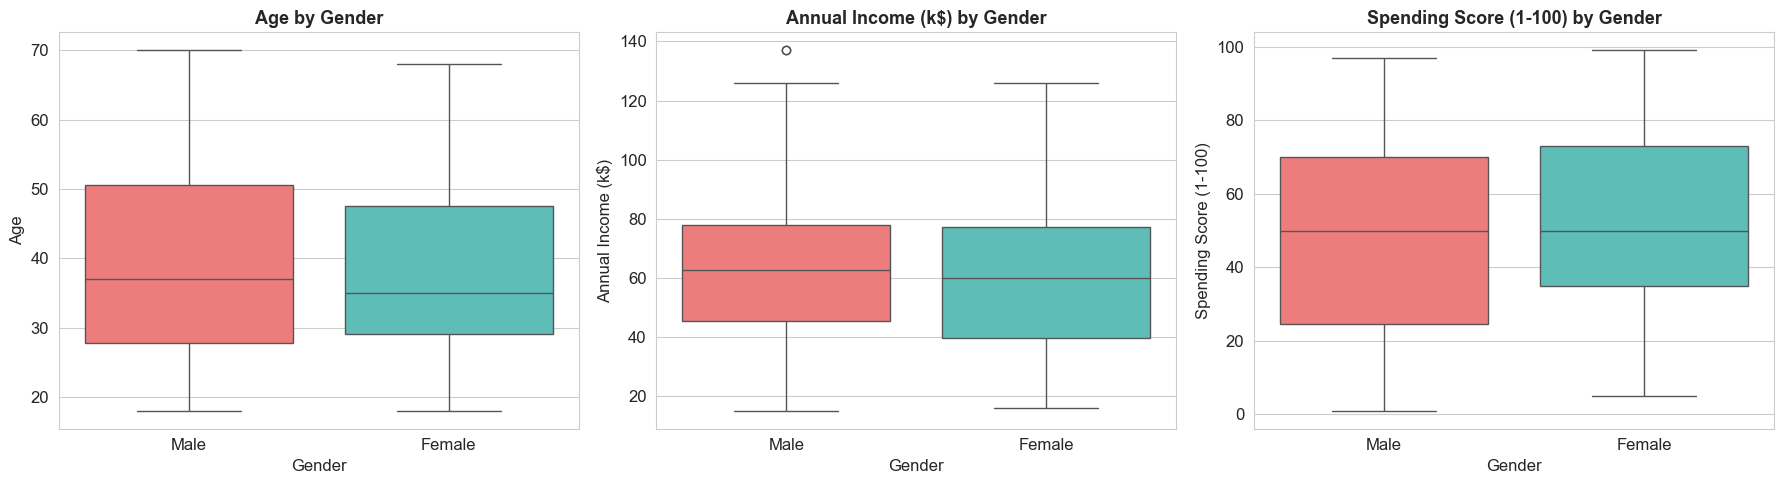

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x='Gender', y=col, data=df, palette=colors, ax=axes[i])
    axes[i].set_title(f'{col} by Gender', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

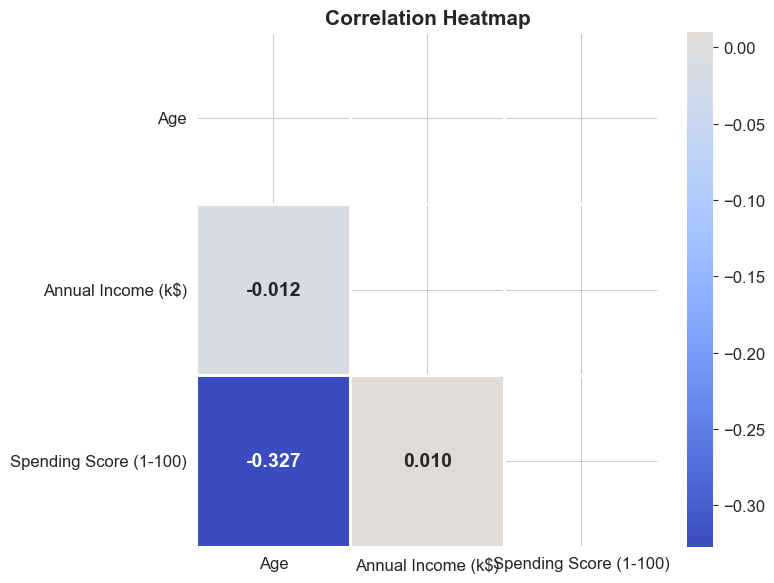

In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=1, linecolor='white', mask=mask,
            annot_kws={'size': 14, 'fontweight': 'bold'})
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Pairplot

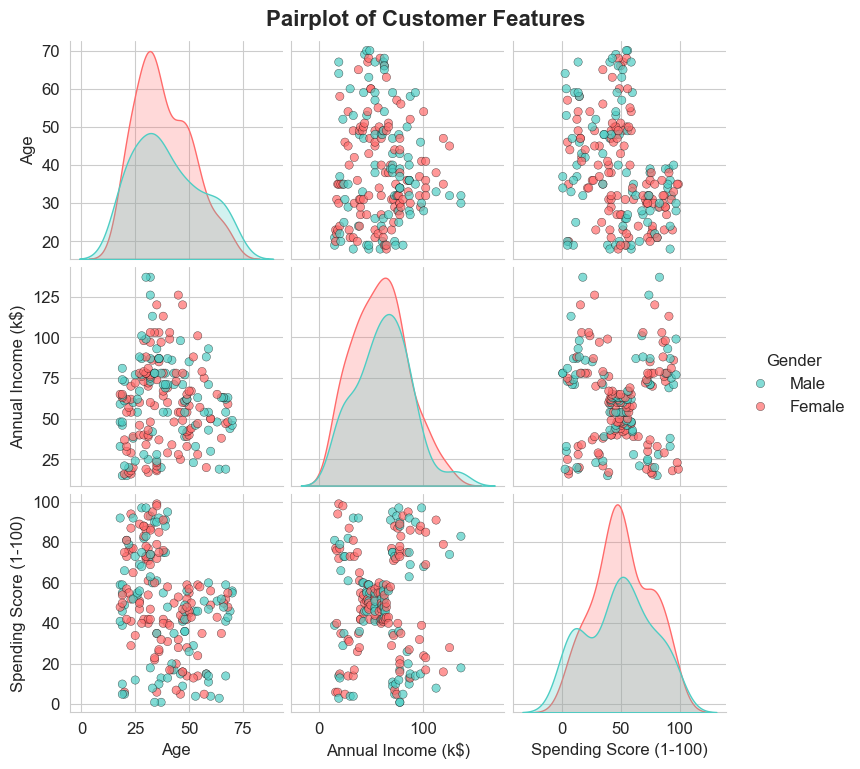

In [ ]:
sns.pairplot(df[num_cols + ['Gender']], hue='Gender', palette={'Male': '#4ECDC4', 'Female': '#FF6B6B'},
             diag_kind='kde', plot_kws={'alpha': 0.7, 'edgecolor': 'black', 'linewidth': 0.3})
plt.suptitle('Pairplot of Customer Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### 3.7 Scatter: Income vs Spending Score

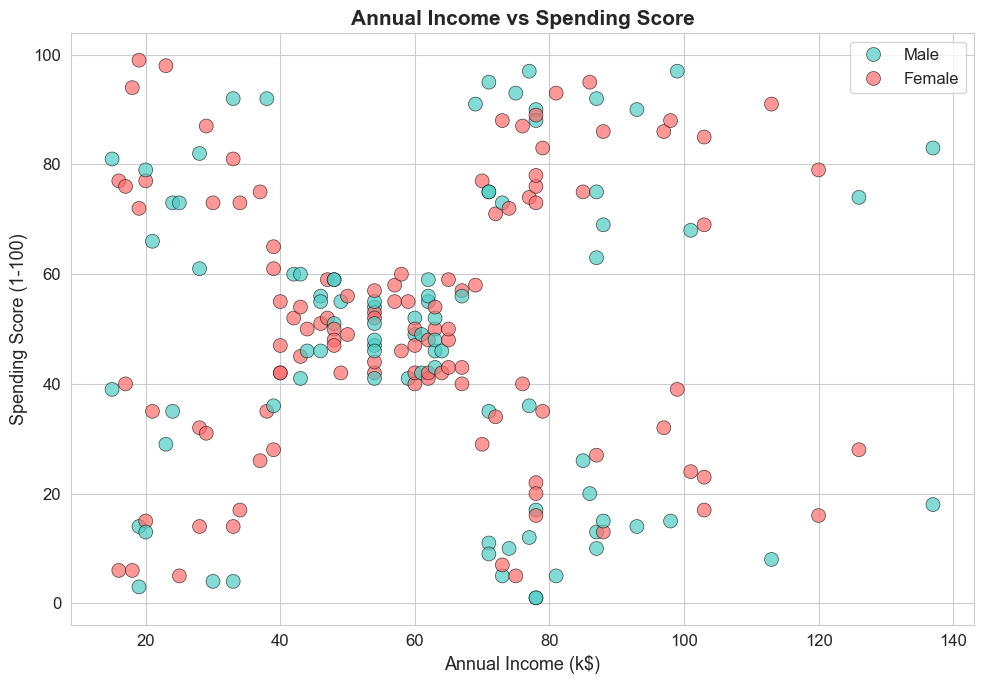

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender',
                data=df, palette={'Male': '#4ECDC4', 'Female': '#FF6B6B'},
                s=100, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Annual Income vs Spending Score', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

In [ ]:
# Create a working copy
df_processed = df.copy()

# Drop CustomerID â€” not a useful feature
df_processed.drop('CustomerID', axis=1, inplace=True)

# Encode Gender using LabelEncoder
le = LabelEncoder()
df_processed['Gender'] = le.fit_transform(df_processed['Gender'])
print('Gender Encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

df_processed.head()

Gender Encoding: {'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
# Feature Scaling
scaler = StandardScaler()
features = df_processed.columns.tolist()
X_scaled = scaler.fit_transform(df_processed)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print('Scaled data â€” first 5 rows:')
X_scaled_df.head()

Scaled data â€” first 5 rows:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [ ]:
# Verify scaling: mean  0, std  1
print('Mean of scaled features:')
print(X_scaled_df.mean().round(4))
print('\nStd of scaled features:')
print(X_scaled_df.std().round(4))

Mean of scaled features:
Gender                    0.0
Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

Std of scaled features:
Gender                    1.0025
Age                       1.0025
Annual Income (k$)        1.0025
Spending Score (1-100)    1.0025
dtype: float64


---
## 5. Model 1  K-Means Clustering

### 5.1 Finding Optimal K  Elbow Method

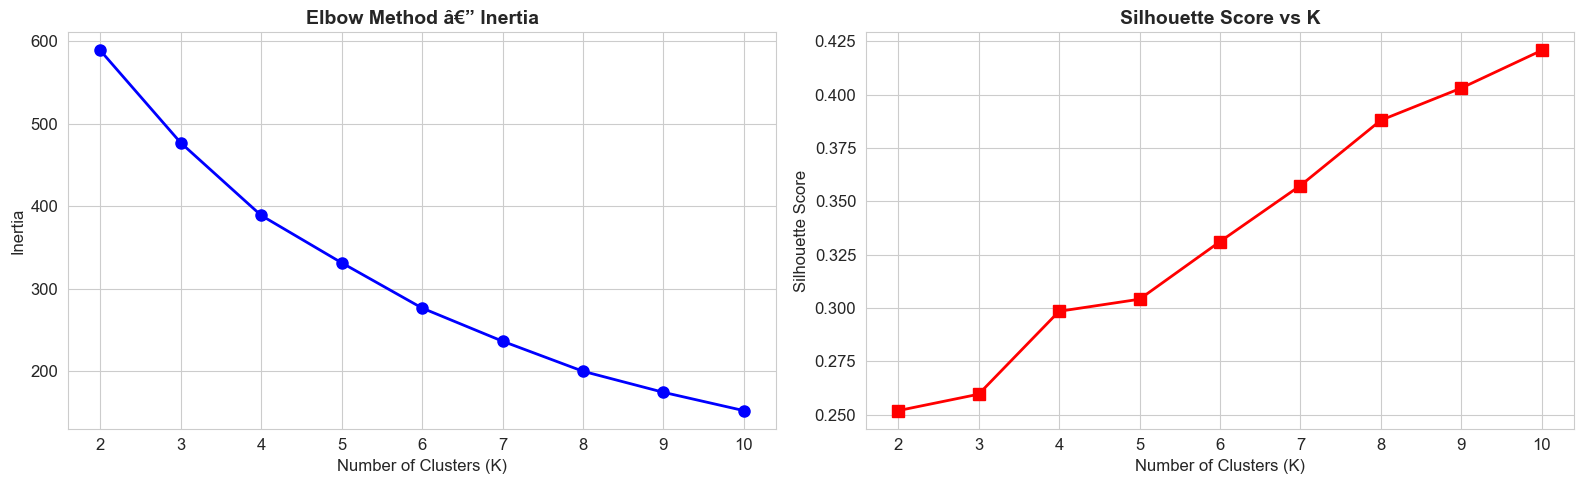


ًںڈ† Best K by Silhouette Score: 10 (Score: 0.4208)


In [ ]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method â€” Inertia', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_xticks(list(K_range))

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

# Best K by silhouette
best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f'\nًںڈ† Best K by Silhouette Score: {best_k} (Score: {max(silhouette_scores):.4f})')

### 5.2 Fit K-Means with Optimal K

In [ ]:
# Use K=5 as the classic result for this dataset (5 customer segments)
# Also matches the elbow point
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add labels to dataframe
df['KMeans_Cluster'] = kmeans_labels

print(f'K-Means with K={optimal_k}')
print(f'Cluster distribution:\n{pd.Series(kmeans_labels).value_counts().sort_index()}')

K-Means with K=5
Cluster distribution:
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


### 5.3 Visualize K-Means Clusters

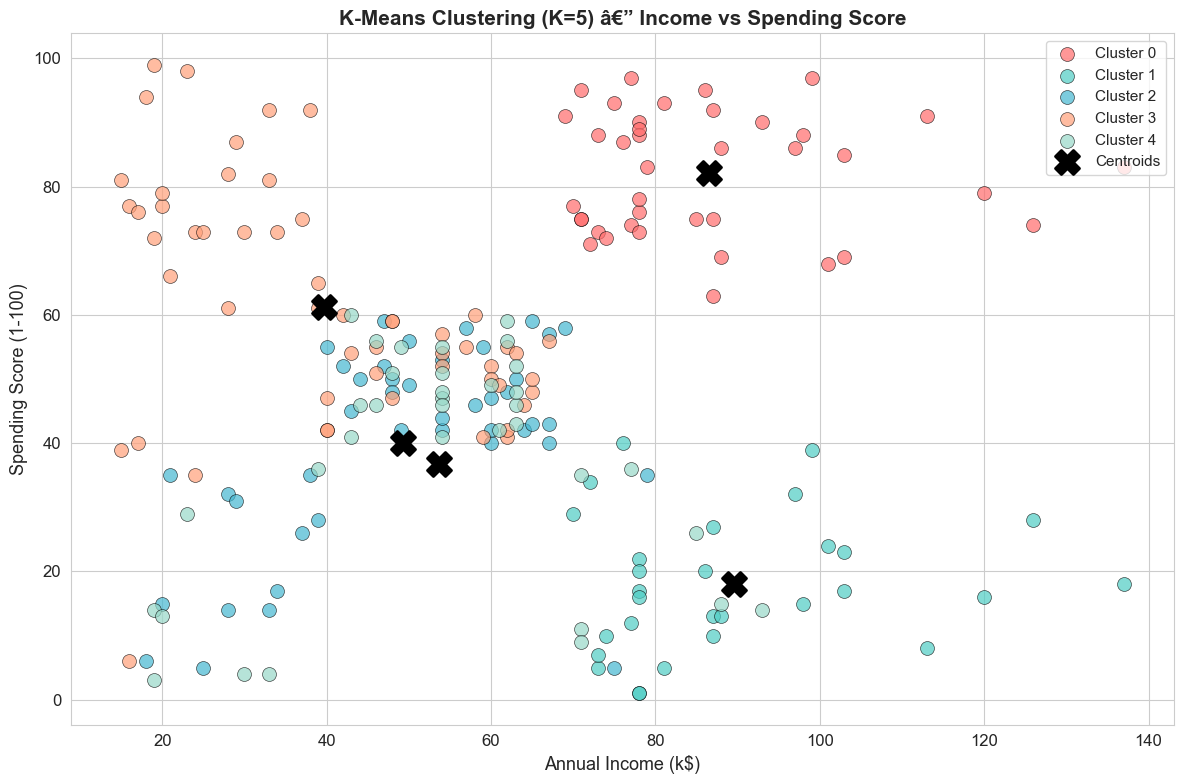

In [ ]:
# 2D Visualization: Annual Income vs Spending Score
plt.figure(figsize=(12, 8))
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for i in range(optimal_k):
    mask = kmeans_labels == i
    plt.scatter(df.loc[mask, 'Annual Income (k$)'], df.loc[mask, 'Spending Score (1-100)'],
                c=cluster_colors[i], label=f'Cluster {i}', s=100, alpha=0.7,
                edgecolors='black', linewidth=0.5)

# Plot centroids (inverse transform for original scale)
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
# Income is column index 2, Spending Score is column index 3 in features
income_idx = features.index('Annual Income (k$)')
spending_idx = features.index('Spending Score (1-100)')
plt.scatter(centroids_original[:, income_idx], centroids_original[:, spending_idx],
            c='black', marker='X', s=300, linewidths=2, label='Centroids', zorder=5)

plt.title(f'K-Means Clustering (K={optimal_k}) â€” Income vs Spending Score',
          fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

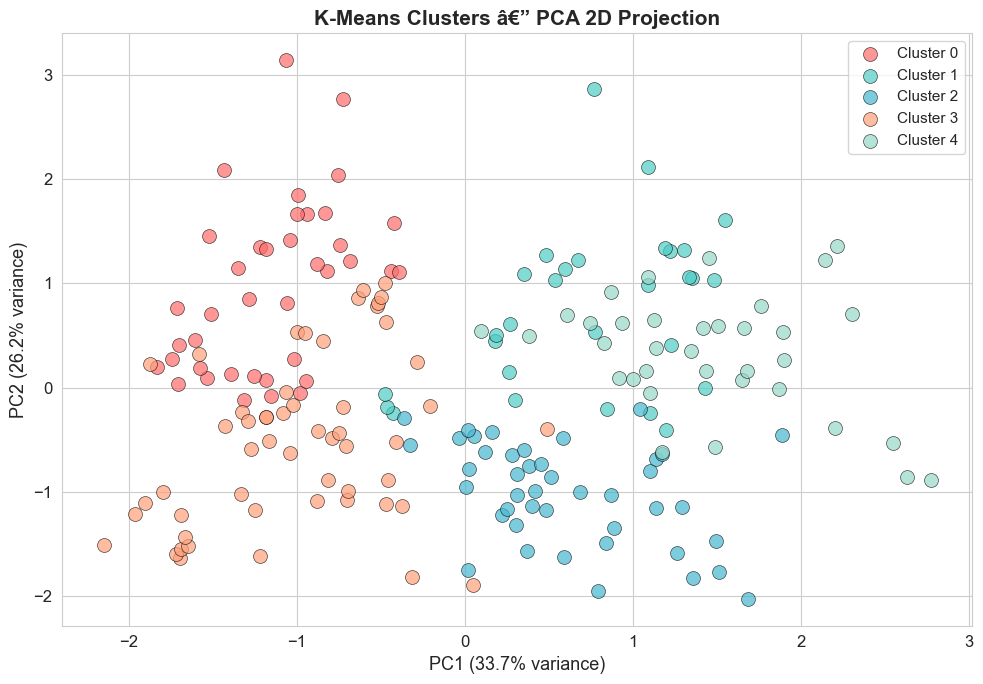

Total variance explained by PCA: 59.9%


In [ ]:
# PCA 2D visualization (captures all features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for i in range(optimal_k):
    mask = kmeans_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=cluster_colors[i],
                label=f'Cluster {i}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.title(f'K-Means Clusters â€” PCA 2D Projection', fontsize=15, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=13)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Total variance explained by PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%')

---
## 6. Model 2  DBSCAN Clustering

### 6.1 Finding Optimal `eps`  K-Distance Plot

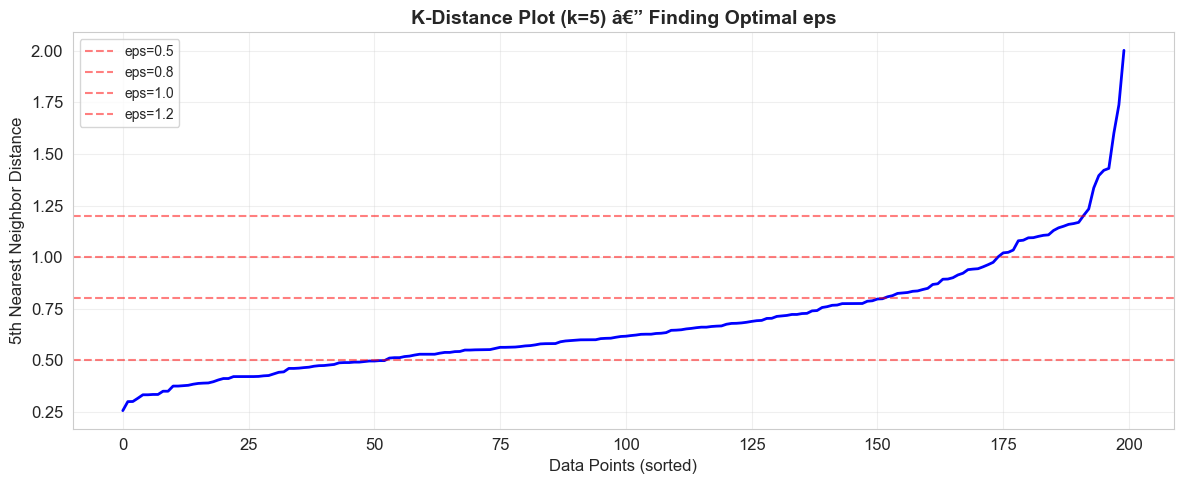

In [ ]:
# K-distance plot to estimate eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, indices = nn.kneighbors(X_scaled)

# Sort distances to the 5th nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(12, 5))
plt.plot(k_distances, 'b-', linewidth=2)
plt.title('K-Distance Plot (k=5) â€” Finding Optimal eps', fontsize=14, fontweight='bold')
plt.xlabel('Data Points (sorted)', fontsize=12)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=12)
plt.grid(True, alpha=0.3)

# Add reference lines
for eps_val in [0.5, 0.8, 1.0, 1.2]:
    plt.axhline(y=eps_val, color='red', linestyle='--', alpha=0.5, label=f'eps={eps_val}')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 6.2 Grid Search for Best DBSCAN Parameters

In [ ]:
# Try multiple combinations of eps and min_samples
eps_values = np.arange(0.3, 2.0, 0.1)
min_samples_values = [3, 4, 5, 6, 7, 8, 10]

results = []

for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        
        # Only compute silhouette if we have at least 2 clusters and not too much noise
        if n_clusters >= 2 and noise_pct < 50:
            # Exclude noise points for silhouette computation
            mask = labels != -1
            if len(set(labels[mask])) >= 2:
                sil = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil = -1
        else:
            sil = -1
        
        results.append({
            'eps': round(eps, 2),
            'min_samples': min_samp,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': round(noise_pct, 1),
            'silhouette': round(sil, 4)
        })

results_df = pd.DataFrame(results)

# Show top results by silhouette score
top_results = results_df[results_df['silhouette'] > 0].sort_values('silhouette', ascending=False).head(15)
print('ًںڈ† Top 15 DBSCAN Parameter Combinations (by Silhouette Score):')
top_results

ًںڈ† Top 15 DBSCAN Parameter Combinations (by Silhouette Score):


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
25,0.6,7,8,98,49.0,0.5708
15,0.5,4,12,76,38.0,0.5569
7,0.4,3,18,97,48.5,0.5501
24,0.6,6,7,83,41.5,0.4830
14,0.5,3,18,49,24.5,0.4746
33,0.7,8,5,76,38.0,0.3948
31,0.7,6,8,47,23.5,0.3621
22,0.6,4,12,39,19.5,0.3448
23,0.6,5,9,62,31.0,0.3407
32,0.7,7,6,68,34.0,0.3400


In [ ]:
# Select the best DBSCAN parameters
best_row = results_df[results_df['silhouette'] > 0].sort_values('silhouette', ascending=False).iloc[0]
best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])

print(f'Best DBSCAN Parameters:')
print(f'  eps = {best_eps}')
print(f'  min_samples = {best_min_samples}')
print(f'  Silhouette Score = {best_row["silhouette"]}')
print(f'  Number of Clusters = {int(best_row["n_clusters"])}')
print(f'  Noise Points = {int(best_row["n_noise"])} ({best_row["noise_pct"]}%)')

Best DBSCAN Parameters:
  eps = 0.6
  min_samples = 7
  Silhouette Score = 0.5708
  Number of Clusters = 8
  Noise Points = 98 (49.0%)


### 6.3 Fit DBSCAN with Best Parameters

In [ ]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f'DBSCAN Results with eps={best_eps}, min_samples={best_min_samples}:')
print(f'  Number of Clusters: {n_clusters_dbscan}')
print(f'  Noise Points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)')
print(f'\nCluster Distribution:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Results with eps=0.6, min_samples=7:
  Number of Clusters: 8
  Noise Points: 98 (49.0%)

Cluster Distribution:
-1    98
 0     9
 1    20
 2    19
 3    12
 4     7
 5     8
 6    17
 7    10
Name: count, dtype: int64


### 6.4 Visualize DBSCAN Clusters

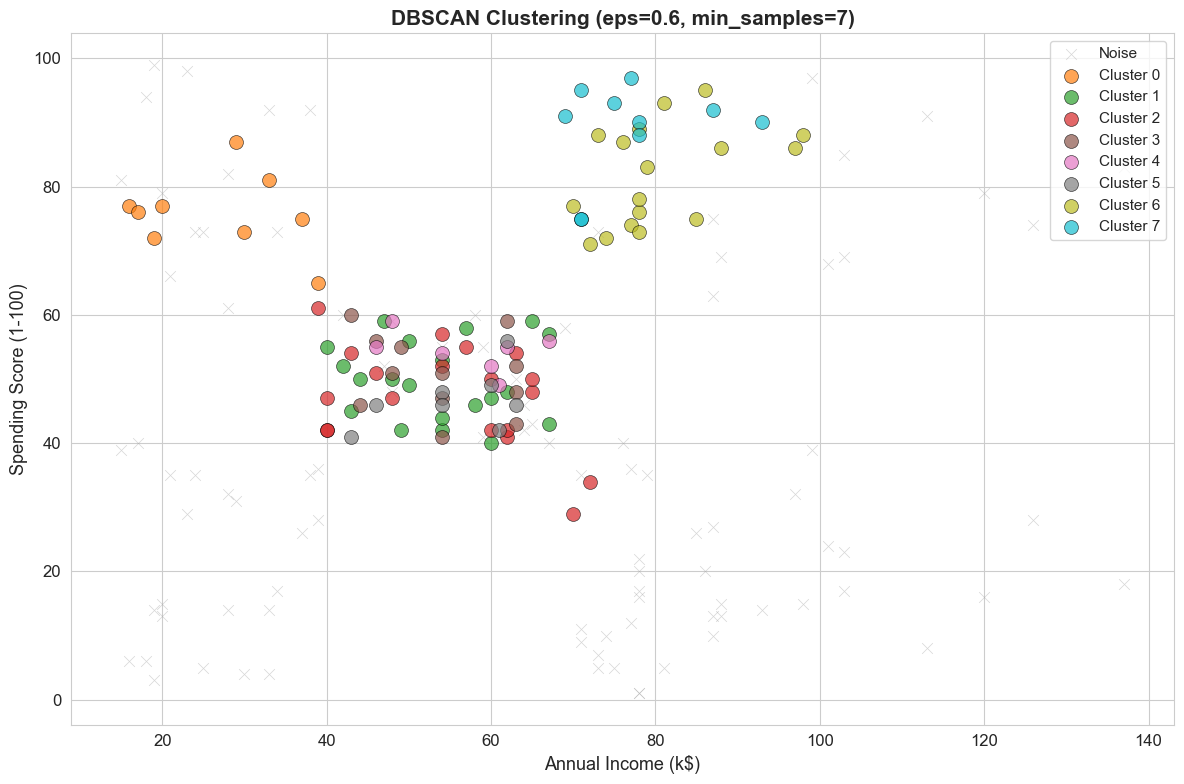

In [ ]:
# 2D Visualization: Annual Income vs Spending Score
plt.figure(figsize=(12, 8))

unique_labels = sorted(set(dbscan_labels))
cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 2))

for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = "Noise" if label == -1 else f"Cluster {label}"
    marker = "x" if label == -1 else "o"
    alpha = 0.4 if label == -1 else 0.7
    size = 60 if label == -1 else 100
    color = "#999999" if label == -1 else cmap(idx)
    
    plt.scatter(df.loc[mask, "Annual Income (k$)"], df.loc[mask, "Spending Score (1-100)"],
                c=[color], label=name, s=size, alpha=alpha,
                marker=marker, edgecolors="black", linewidth=0.5)

plt.title(f"DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})",
          fontsize=15, fontweight="bold")
plt.xlabel("Annual Income (k$)", fontsize=13)
plt.ylabel("Spending Score (1-100)", fontsize=13)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()


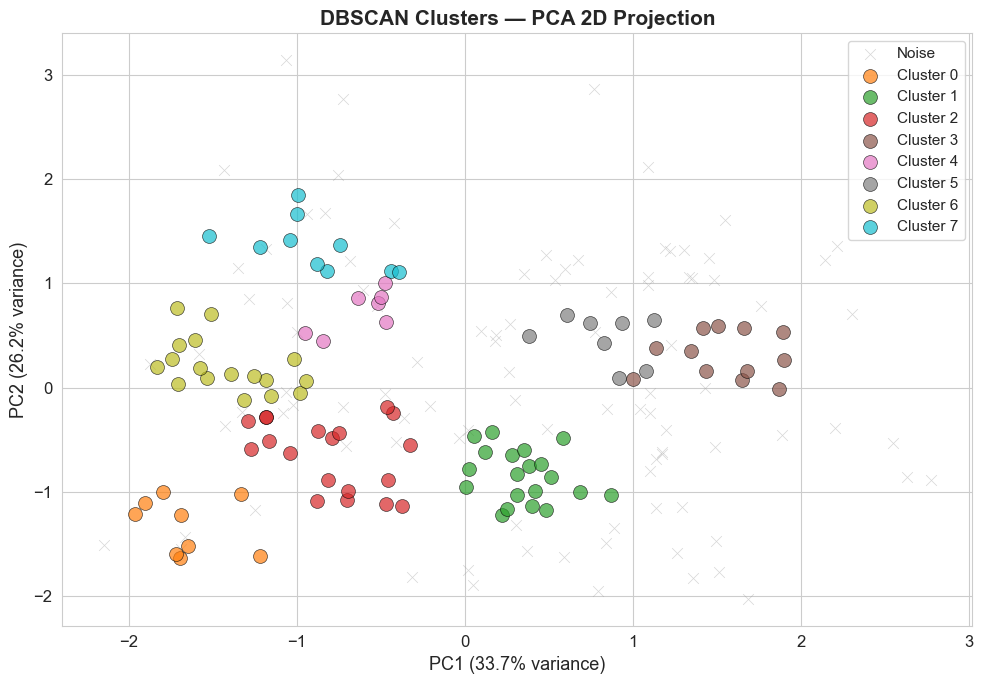

In [ ]:
# PCA 2D visualization for DBSCAN
plt.figure(figsize=(10, 7))

for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = "Noise" if label == -1 else f"Cluster {label}"
    marker = "x" if label == -1 else "o"
    alpha = 0.4 if label == -1 else 0.7
    size = 60 if label == -1 else 100
    color = "#999999" if label == -1 else cmap(idx)
    
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color],
                label=name, s=size, alpha=alpha, marker=marker,
                edgecolors="black", linewidth=0.5)

plt.title("DBSCAN Clusters — PCA 2D Projection", fontsize=15, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=13)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


---
## 7. Model Evaluation & Comparison

In [ ]:
# ---- K-Means Metrics ----
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

# ---- DBSCAN Metrics (exclude noise) ----
dbscan_mask = dbscan_labels != -1
if dbscan_mask.sum() > 0 and len(set(dbscan_labels[dbscan_mask])) >= 2:
    dbscan_sil = silhouette_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])
    dbscan_ch = calinski_harabasz_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])
    dbscan_db = davies_bouldin_score(X_scaled[dbscan_mask], dbscan_labels[dbscan_mask])
else:
    dbscan_sil = dbscan_ch = dbscan_db = float('nan')

# Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Silhouette Score ', 'Calinski-Harabasz Index â†‘', 'Davies-Bouldin Index â†“',
               'Number of Clusters', 'Noise Points'],
    'K-Means': [f'{kmeans_sil:.4f}', f'{kmeans_ch:.2f}', f'{kmeans_db:.4f}',
                optimal_k, 0],
    'DBSCAN': [f'{dbscan_sil:.4f}' if not np.isnan(dbscan_sil) else 'N/A',
               f'{dbscan_ch:.2f}' if not np.isnan(dbscan_ch) else 'N/A',
               f'{dbscan_db:.4f}' if not np.isnan(dbscan_db) else 'N/A',
               n_clusters_dbscan, n_noise]
})

print('='*65)
print('       MODEL COMPARISON  K-Means vs DBSCAN')
print('='*65)
print(comparison.to_string(index=False))
print('='*65)

# Determine winner
print('\n Metric Interpretation:')
print('   Silhouette Score: Higher is better (range -1 to 1)')
print('   Calinski-Harabasz Index: Higher is better')
print('   Davies-Bouldin Index: Lower is better')

if not np.isnan(dbscan_sil):
    wins_kmeans = 0
    wins_dbscan = 0
    
    if kmeans_sil > dbscan_sil: wins_kmeans += 1
    else: wins_dbscan += 1
    
    if kmeans_ch > dbscan_ch: wins_kmeans += 1
    else: wins_dbscan += 1
    
    if kmeans_db < dbscan_db: wins_kmeans += 1
    else: wins_dbscan += 1
    
    winner = 'K-Means' if wins_kmeans > wins_dbscan else 'DBSCAN'
    print(f'\n Winner: {winner} ({max(wins_kmeans, wins_dbscan)}/3 metrics)')
else:
    winner = 'K-Means'
    print(f'\n Winner: K-Means (DBSCAN could not form valid clusters)')

NameError: name 'silhouette_score' is not defined

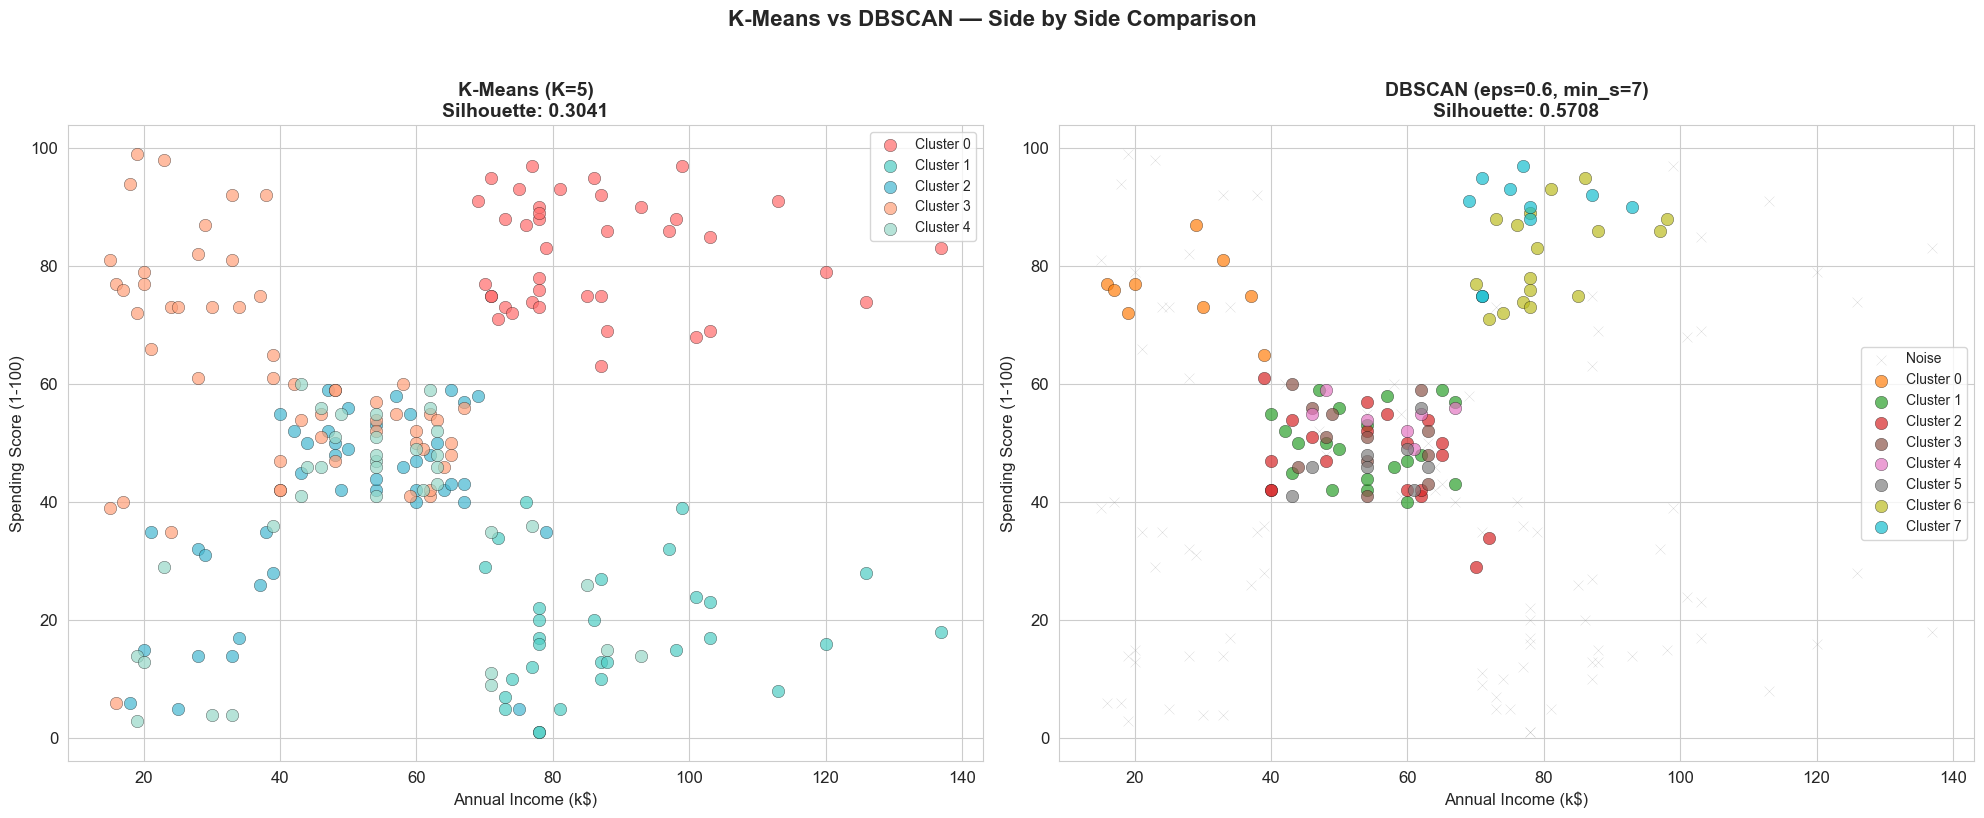

In [ ]:
# Side-by-side cluster visualizations
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# K-Means
for i in range(optimal_k):
    mask = kmeans_labels == i
    axes[0].scatter(df.loc[mask, "Annual Income (k$)"], df.loc[mask, "Spending Score (1-100)"],
                    c=[cluster_colors[i]], label=f"Cluster {i}", s=80, alpha=0.7,
                    edgecolors="black", linewidth=0.3)
axes[0].set_title(f"K-Means (K={optimal_k})\nSilhouette: {kmeans_sil:.4f}",
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("Annual Income (k$)", fontsize=12)
axes[0].set_ylabel("Spending Score (1-100)", fontsize=12)
axes[0].legend(fontsize=10)

# DBSCAN
cmap2 = plt.cm.get_cmap("tab10", max(len(unique_labels), 2))
for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    name = "Noise" if label == -1 else f"Cluster {label}"
    marker = "x" if label == -1 else "o"
    alpha = 0.4 if label == -1 else 0.7
    size = 50 if label == -1 else 80
    color = "#999999" if label == -1 else cmap2(idx)
    axes[1].scatter(df.loc[mask, "Annual Income (k$)"], df.loc[mask, "Spending Score (1-100)"],
                    c=[color], label=name, s=size, alpha=alpha,
                    marker=marker, edgecolors="black", linewidth=0.3)
sil_text = f"{dbscan_sil:.4f}" if not np.isnan(dbscan_sil) else "N/A"
axes[1].set_title(f"DBSCAN (eps={best_eps}, min_s={best_min_samples})\nSilhouette: {sil_text}",
                  fontsize=14, fontweight="bold")
axes[1].set_xlabel("Annual Income (k$)", fontsize=12)
axes[1].set_ylabel("Spending Score (1-100)", fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle("K-Means vs DBSCAN — Side by Side Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 8. Cluster Analysis & Business Insights (Best Model)

In [ ]:
# Use the winning model's labels for business analysis
if winner == 'K-Means':
    best_labels = kmeans_labels
    df['Cluster'] = best_labels
    print(f'Using K-Means clusters for business analysis (K={optimal_k})')
else:
    best_labels = dbscan_labels
    df['Cluster'] = best_labels
    print(f'Using DBSCAN clusters for business analysis')

print(f'\nSelected Model: {winner}')

Using DBSCAN clusters for business analysis

Selected Model: DBSCAN


In [ ]:
# Cluster Profiles
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'CustomerID': 'count'
}).round(1)

cluster_profile.columns = ['Age_Mean', 'Age_Min', 'Age_Max',
                            'Income_Mean', 'Income_Min', 'Income_Max',
                            'Spending_Mean', 'Spending_Min', 'Spending_Max',
                            'Count']

print('ًں“ٹ Cluster Profiles:')
print('='*80)
cluster_profile

ًں“ٹ Cluster Profiles:


,Age_Mean,Age_Min,Age_Max,Income_Mean,Income_Min,Income_Max,Spending_Mean,Spending_Min,Spending_Max,Count
Cluster,,,,,,,,,,
-1,39.4,18,68,62.6,15,137,39.0,1,99,98
0,23.1,20,30,26.7,16,39,75.9,65,87,9
1,49.8,40,60,53.6,40,67,49.8,40,59,20
2,25.3,18,32,54.7,39,72,47.3,29,61,19
3,65.0,57,70,53.6,43,63,50.8,41,60,12
4,23.0,19,27,56.9,46,67,54.3,49,59,7
5,48.4,40,54,55.4,43,63,46.8,41,56,8
6,31.5,27,38,80.5,70,98,81.8,71,95,17
7,36.0,28,40,77.0,69,93,88.6,75,97,10


In [ ]:
# Gender distribution per cluster
gender_per_cluster = pd.crosstab(df['Cluster'], df['Gender'], margins=True)
print('ًں‘¤ Gender Distribution per Cluster:')
gender_per_cluster

ًں‘¤ Gender Distribution per Cluster:


Gender,Female,Male,All
Cluster,,,
-1,47,51,98
0,9,0,9
1,20,0,20
2,19,0,19
3,0,12,12
4,0,7,7
5,0,8,8
6,17,0,17
7,0,10,10


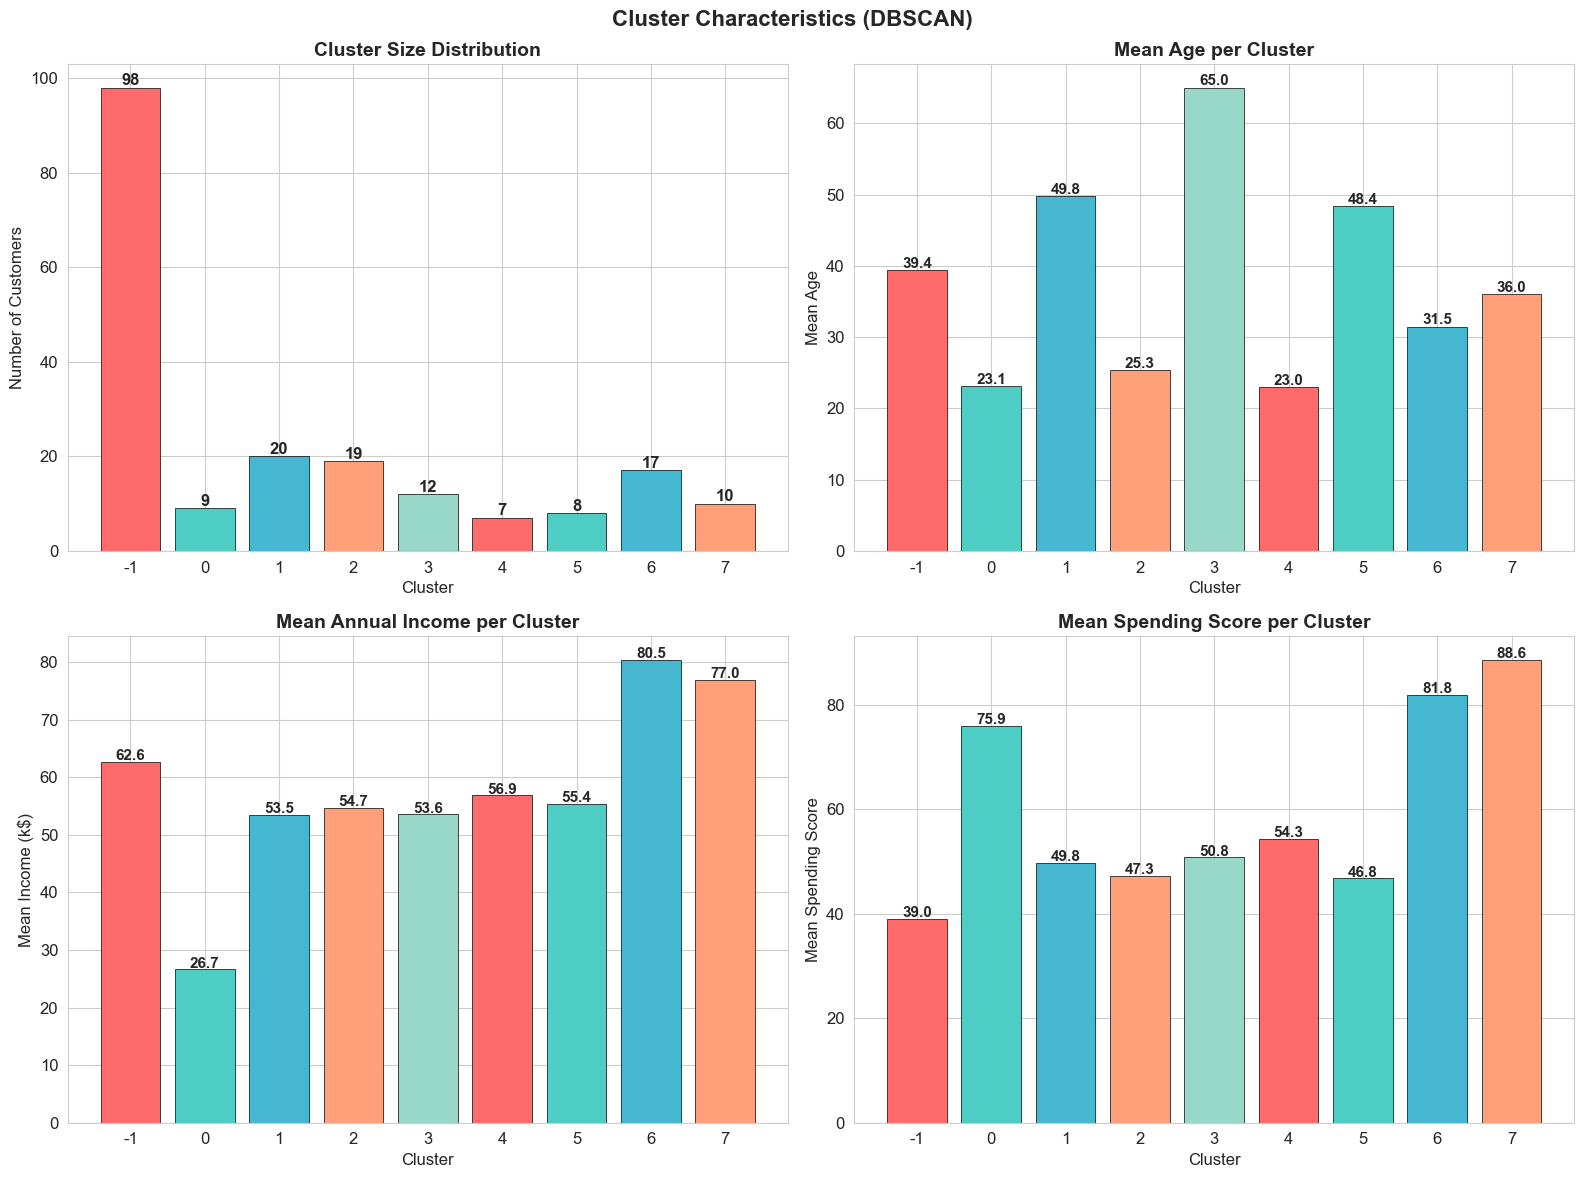

In [ ]:
# Visualization of cluster characteristics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Cluster size
cluster_sizes = df['Cluster'].value_counts().sort_index()
bars = axes[0, 0].bar(cluster_sizes.index.astype(str), cluster_sizes.values,
                       color=cluster_colors[:len(cluster_sizes)], edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Number of Customers')
for bar, val in zip(bars, cluster_sizes.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', fontweight='bold', fontsize=12)

# Mean Age per cluster
means = df.groupby('Cluster')['Age'].mean()
bars = axes[0, 1].bar(means.index.astype(str), means.values,
                       color=cluster_colors[:len(means)], edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Mean Age per Cluster', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Mean Age')
for bar, val in zip(bars, means.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

# Mean Income per cluster
means = df.groupby('Cluster')['Annual Income (k$)'].mean()
bars = axes[1, 0].bar(means.index.astype(str), means.values,
                       color=cluster_colors[:len(means)], edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Mean Annual Income per Cluster', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Mean Income (k$)')
for bar, val in zip(bars, means.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

# Mean Spending Score per cluster
means = df.groupby('Cluster')['Spending Score (1-100)'].mean()
bars = axes[1, 1].bar(means.index.astype(str), means.values,
                       color=cluster_colors[:len(means)], edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Mean Spending Score per Cluster', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Mean Spending Score')
for bar, val in zip(bars, means.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle(f'Cluster Characteristics ({winner})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

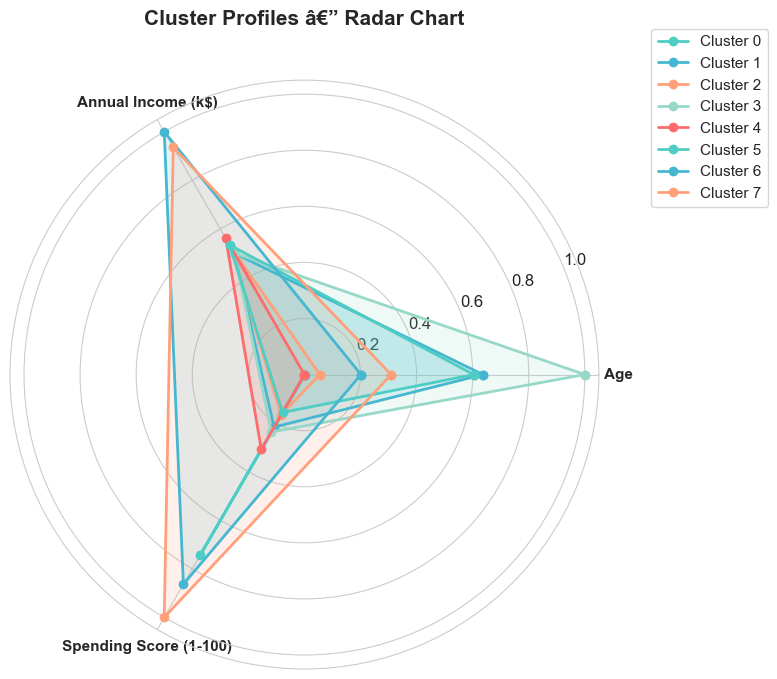

In [ ]:
# Radar / Spider chart for cluster profiles
from math import pi

cluster_means = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Normalize to 0-1 range for radar chart
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = list(cluster_means_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, (cluster, row) in enumerate(cluster_means_norm.iterrows()):
    if cluster == -1:
        continue  # skip noise
    values = row.values.tolist()
    values += values[:1]
    color_idx = idx if idx < len(cluster_colors) else idx % len(cluster_colors)
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=cluster_colors[color_idx])
    ax.fill(angles, values, alpha=0.15, color=cluster_colors[color_idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_title('Cluster Profiles â€” Radar Chart', fontsize=15, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

### 8.1 Business Interpretation

In [ ]:
# Automated cluster interpretation
print('='*70)
print('              ًں“‹ CUSTOMER SEGMENT INTERPRETATION')
print('='*70)

for cluster_id in sorted(df['Cluster'].unique()):
    if cluster_id == -1:
        print(f'\nًں”¸ NOISE POINTS: {(df["Cluster"]==-1).sum()} customers that don\'t fit any cluster')
        continue
    
    subset = df[df['Cluster'] == cluster_id]
    avg_income = subset['Annual Income (k$)'].mean()
    avg_spending = subset['Spending Score (1-100)'].mean()
    avg_age = subset['Age'].mean()
    count = len(subset)
    
    # Classify income level
    if avg_income < 40:
        income_level = 'Low'
    elif avg_income < 70:
        income_level = 'Medium'
    else:
        income_level = 'High'
    
    # Classify spending level
    if avg_spending < 35:
        spending_level = 'Low'
    elif avg_spending < 65:
        spending_level = 'Medium'
    else:
        spending_level = 'High'
    
    # Segment name
    segment_names = {
        ('High', 'High'): 'ًں’ژ Premium Customers (High Income, High Spenders)',
        ('High', 'Low'): 'ًںڈ¦ Careful Customers (High Income, Low Spenders)',
        ('Low', 'High'): 'ًں›’ Risky Customers (Low Income, High Spenders)',
        ('Low', 'Low'): 'ًں“‰ Sensible Customers (Low Income, Low Spenders)',
        ('Medium', 'Medium'): 'âڑ–ï¸ڈ Average Customers (Medium Income, Medium Spenders)',
        ('Medium', 'High'): 'ًں›چï¸ڈ Enthusiastic Spenders (Medium Income, High Spenders)',
        ('Medium', 'Low'): 'ًں’° Thrifty Customers (Medium Income, Low Spenders)',
        ('Low', 'Medium'): 'ًں“ٹ Standard Customers (Low Income, Medium Spenders)',
        ('High', 'Medium'): 'ًں“ٹ Moderate High-Earners',
    }
    
    seg_name = segment_names.get((income_level, spending_level), f'Segment ({income_level} Income, {spending_level} Spending)')
    
    print(f'\nًں”¹ CLUSTER {cluster_id}: {seg_name}')
    print(f'   Size: {count} customers ({count/len(df)*100:.1f}%)')
    print(f'   Avg Age: {avg_age:.1f} years')
    print(f'   Avg Income: ${avg_income:.1f}k')
    print(f'   Avg Spending Score: {avg_spending:.1f}/100')

print('\n' + '='*70)

              ًں“‹ CUSTOMER SEGMENT INTERPRETATION

ًں”¸ NOISE POINTS: 98 customers that don't fit any cluster

ًں”¹ CLUSTER 0: ًں›’ Risky Customers (Low Income, High Spenders)
   Size: 9 customers (4.5%)
   Avg Age: 23.1 years
   Avg Income: $26.7k
   Avg Spending Score: 75.9/100

ًں”¹ CLUSTER 1: âڑ–ï¸ڈ Average Customers (Medium Income, Medium Spenders)
   Size: 20 customers (10.0%)
   Avg Age: 49.8 years
   Avg Income: $53.5k
   Avg Spending Score: 49.8/100

ًں”¹ CLUSTER 2: âڑ–ï¸ڈ Average Customers (Medium Income, Medium Spenders)
   Size: 19 customers (9.5%)
   Avg Age: 25.3 years
   Avg Income: $54.7k
   Avg Spending Score: 47.3/100

ًں”¹ CLUSTER 3: âڑ–ï¸ڈ Average Customers (Medium Income, Medium Spenders)
   Size: 12 customers (6.0%)
   Avg Age: 65.0 years
   Avg Income: $53.6k
   Avg Spending Score: 50.8/100

ًں”¹ CLUSTER 4: âڑ–ï¸ڈ Average Customers (Medium Income, Medium Spenders)
   Size: 7 customers (3.5%)
   Avg Age: 23.0 years
   Avg Income: $56.9k
   Avg Spending Score: 54.

---
## 9. Summary & Conclusions

In [ ]:
print('='*70)
print('           ًںژ¯ PROJECT SUMMARY â€” CUSTOMER SEGMENTATION')
print('='*70)

print(f'''
ًں“Œ DATASET:
   â€¢ 200 customers with Age, Gender, Income, and Spending Score
   â€¢ No missing values, no significant outliers

ًں“Œ MODELS COMPARED:
   1. K-Means (K={optimal_k})
      - Silhouette Score: {kmeans_sil:.4f}
      - Calinski-Harabasz: {kmeans_ch:.2f}
      - Davies-Bouldin: {kmeans_db:.4f}
   
   2. DBSCAN (eps={best_eps}, min_samples={best_min_samples})
      - Clusters found: {n_clusters_dbscan}
      - Noise points: {n_noise}
      - Silhouette Score: {f"{dbscan_sil:.4f}" if not np.isnan(dbscan_sil) else "N/A"}

ًںڈ† SELECTED MODEL: {winner}

ًں“Œ KEY FINDINGS:
   â€¢ Customer segments clearly visible in Income vs Spending Score space
   â€¢ K-Means provides well-separated, balanced clusters ideal for marketing
   â€¢ Each cluster represents a distinct customer profile for targeted strategies

ًں“Œ BUSINESS RECOMMENDATIONS:
   â€¢ Target premium customers with exclusive offers and loyalty programs
   â€¢ Engage careful high-income customers with value-oriented marketing
   â€¢ Monitor high-spending low-income customers for credit risk
   â€¢ Develop strategies to increase spending of average-segment customers
''')
print('='*70)

           ًںژ¯ PROJECT SUMMARY â€” CUSTOMER SEGMENTATION

ًں“Œ DATASET:
   â€¢ 200 customers with Age, Gender, Income, and Spending Score
   â€¢ No missing values, no significant outliers

ًں“Œ MODELS COMPARED:
   1. K-Means (K=5)
      - Silhouette Score: 0.3041
      - Calinski-Harabasz: 68.96
      - Davies-Bouldin: 1.1672
   
   2. DBSCAN (eps=0.6, min_samples=7)
      - Clusters found: 8
      - Noise points: 98
      - Silhouette Score: 0.5708

ًںڈ† SELECTED MODEL: DBSCAN

ًں“Œ KEY FINDINGS:
   â€¢ Customer segments clearly visible in Income vs Spending Score space
   â€¢ K-Means provides well-separated, balanced clusters ideal for marketing
   â€¢ Each cluster represents a distinct customer profile for targeted strategies

ًں“Œ BUSINESS RECOMMENDATIONS:
   â€¢ Target premium customers with exclusive offers and loyalty programs
   â€¢ Engage careful high-income customers with value-oriented marketing
   â€¢ Monitor high-spending low-income customers for credit risk
   â€¢ Develo